# Exploración de Datos — Urban Growth Colombia

Notebook de validación post-Paso 0.  
Verifica alineación espacial, distribución de valores y completitud de los datasets procesados.

**Prerequisito:** Haber ejecutado `python scripts/paso0_estandarizacion/run_paso0.py`

In [2]:
import sys
from pathlib import Path

# Agregar raíz del proyecto al path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.plot import show as rshow

from config.settings import (
    CLIPPED_DIR, SLOPE_DIR, VECTORS_DIR, LOGS_DIR,
    GHSL_YEARS, COMMON_YEARS, DEM_NODATA, HANSEN_NODATA
)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Rasters procesados: {len(list(CLIPPED_DIR.glob('*.tif')))} TIFs")
print(f"Vectores: {len(list(VECTORS_DIR.glob('*.gpkg')))} GPKGs")

Proyecto: C:\Users\GuachetaW\Documents\PROYECTO_2\urban-growth-colombia
Rasters procesados: 40 TIFs
Vectores: 4 GPKGs


## 1. Reporte de integridad

In [3]:
integrity = pd.read_csv(LOGS_DIR / "integrity_report.csv")
print(f"Checks totales: {len(integrity)} | OK: {(integrity.status=='OK').sum()} | FAIL: {(integrity.status=='FAIL').sum()}")
integrity.style.apply(
    lambda col: ['background-color: #d4edda' if v == 'OK' else 'background-color: #f8d7da' for v in col],
    subset=['status']
)

Checks totales: 10 | OK: 10 | FAIL: 0


,check_name,status,detail,timestamp
0,mosaicos_ghsl_presentes,OK,37/37 presentes,2026-06-09T16:55:42.275729
1,mosaico_hansen_presente,OK,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-growth-colombia\data\processed\mosaics\hansen_lossyear_mosaic_4326.tif,2026-06-09T16:55:42.275778
2,crs_rasters_clipped,OK,40 rasters revisados | Todos en EPSG:9377 (verificado por WKT),2026-06-09T16:55:44.360380
3,resolucion_100m_clipped,OK,40 rasters revisados | Todos a 100m,2026-06-09T16:55:45.830533
4,bounds_dentro_colombia,OK,40 revisados,2026-06-09T16:55:47.321437
5,built_s_2018_100m,OK,res: 100.00 × 100.00 m (esperado 100m ±1.0m),2026-06-09T16:55:47.333148
6,hansen_valores_rango,OK,"min=0, max=25 (esperado 0–25)",2026-06-09T16:55:48.341683
7,crs_vectores_9377,OK,4 GPKGs revisados | Todos en EPSG:9377,2026-06-09T16:55:48.491257
8,runap_features,OK,1879 áreas protegidas (mínimo esperado: 100),2026-06-09T16:55:48.675094
9,ucdb_dentro_colombia,OK,85/85 centros urbanos dentro del límite Colombia,2026-06-09T16:55:48.921776


## 2. Auditoría de CRS

In [4]:
audit = pd.read_csv(LOGS_DIR / "crs_audit.csv")
print("CRS encontrados:")
display(audit.groupby(['file_type', 'epsg']).size().reset_index(name='n_archivos'))
sin_crs = audit[audit['flag_no_crs'] == True]
if len(sin_crs) > 0:
    print(f"\n⚠ {len(sin_crs)} archivo(s) sin CRS definido:")
    display(sin_crs[['path', 'file_type', 'status']])

CRS encontrados:


,file_type,epsg,n_archivos
0,vector,4686.0,2



⚠ 200 archivo(s) sin CRS definido:


,path,file_type,status
0,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,raster,OK
1,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,raster,OK
2,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,raster,OK
3,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,raster,OK
4,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,raster,OK
...,...,...,...
195,d:\PROYECTO_CLAUDE_DATA\Hansen Global Forest C...,raster,OK
196,d:\PROYECTO_CLAUDE_DATA\Hansen Global Forest C...,raster,OK
197,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,vector,OK
198,C:\Users\GuachetaW\Documents\PROYECTO_2\urban-...,vector,OK


## 3. Visualización del límite de Colombia y vectores

C:\Users\GuachetaW\AppData\Local\Temp\ipykernel_40480\2702280523.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\GuachetaW\AppData\Local\Temp\ipykernel_40480\2702280523.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


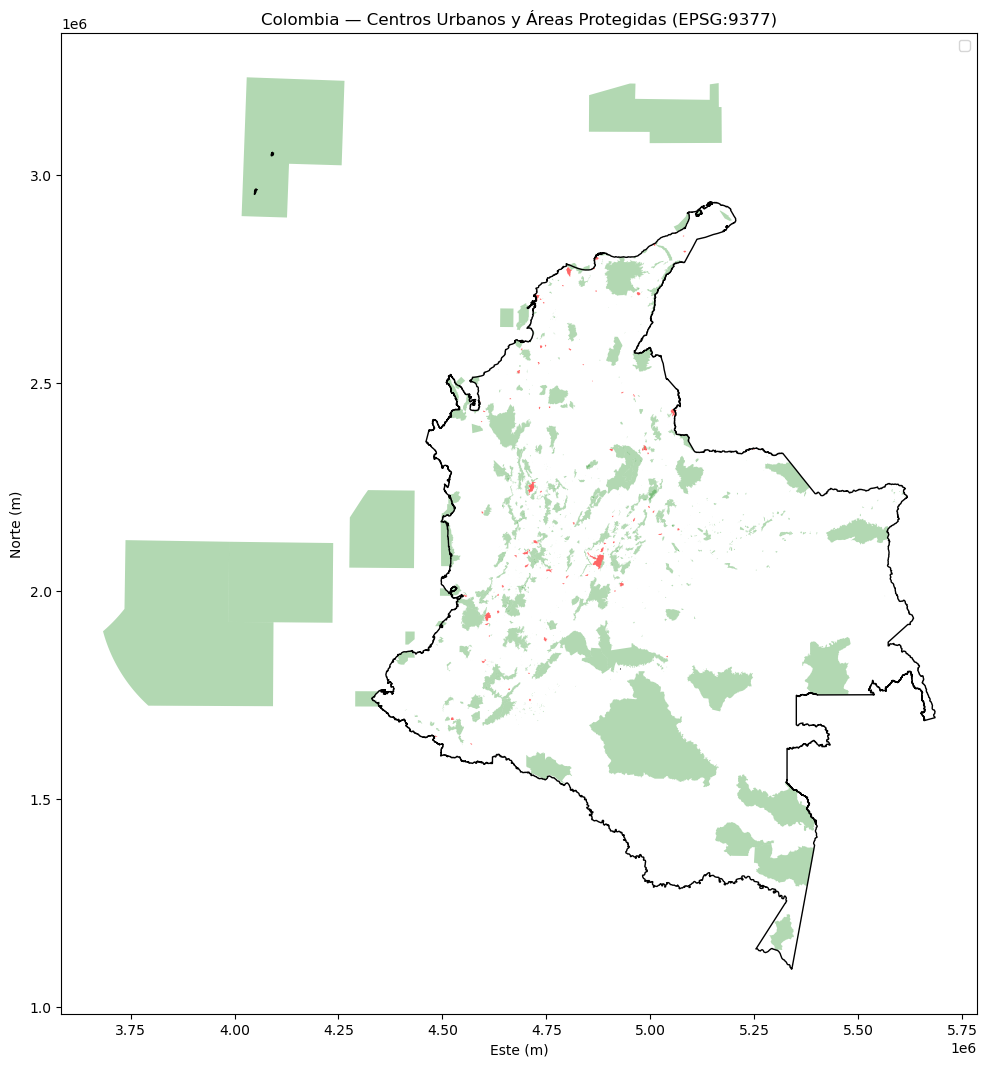

UCDB: 85 centros urbanos
RUNAP: 1879 áreas protegidas


In [5]:
gdf_limite = gpd.read_file(VECTORS_DIR / "limite_colombia_9377.gpkg")
gdf_ucdb   = gpd.read_file(VECTORS_DIR / "ucdb_colombia.gpkg")
gdf_runap  = gpd.read_file(VECTORS_DIR / "runap.gpkg")

fig, ax = plt.subplots(figsize=(10, 12))
gdf_limite.boundary.plot(ax=ax, color='black', linewidth=1)
gdf_runap.plot(ax=ax, color='green', alpha=0.3, label='RUNAP')
gdf_ucdb.plot(ax=ax, color='red', alpha=0.6, markersize=8, label='Centros urbanos')
ax.set_title('Colombia — Centros Urbanos y Áreas Protegidas (EPSG:9377)', fontsize=12)
ax.legend()
ax.set_xlabel('Este (m)')
ax.set_ylabel('Norte (m)')
plt.tight_layout()
plt.show()

print(f"UCDB: {len(gdf_ucdb)} centros urbanos")
print(f"RUNAP: {len(gdf_runap)} áreas protegidas")

## 4. Vista rápida del DEM y pendiente

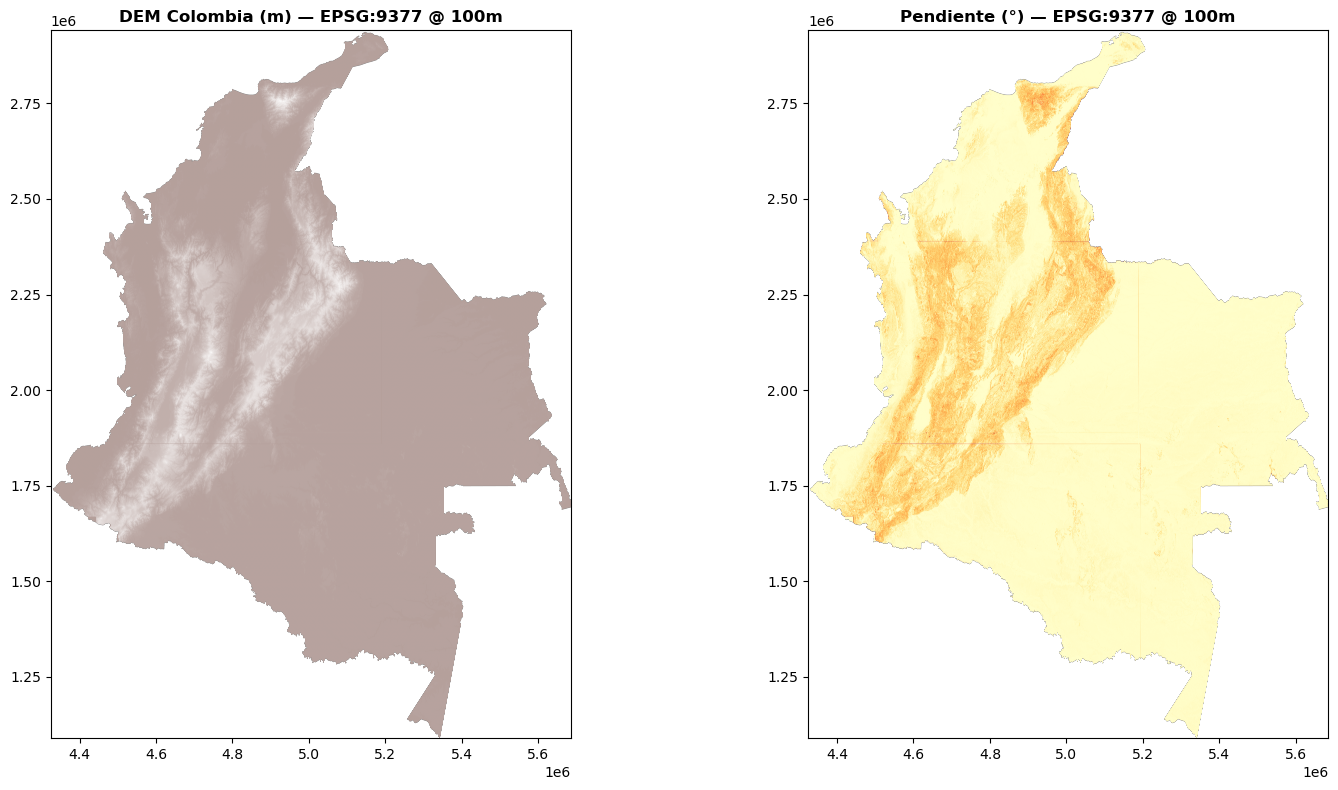

DEM — min: -32767m | max: 5662m | media: 557m


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

with rasterio.open(CLIPPED_DIR / "dem_col.tif") as src:
    dem_data = src.read(1).astype(float)
    dem_data[dem_data == DEM_NODATA] = np.nan
    rshow(src, ax=axes[0], cmap='terrain', title='DEM Colombia (m) — EPSG:9377 @ 100m')

with rasterio.open(SLOPE_DIR / "slope_col.tif") as src:
    rshow(src, ax=axes[1], cmap='YlOrRd', title='Pendiente (°) — EPSG:9377 @ 100m')

plt.tight_layout()
plt.show()

print(f"DEM — min: {np.nanmin(dem_data):.0f}m | max: {np.nanmax(dem_data):.0f}m | media: {np.nanmean(dem_data):.0f}m")

## 5. Serie temporal GHS-BUILT-S (área construida total Colombia)

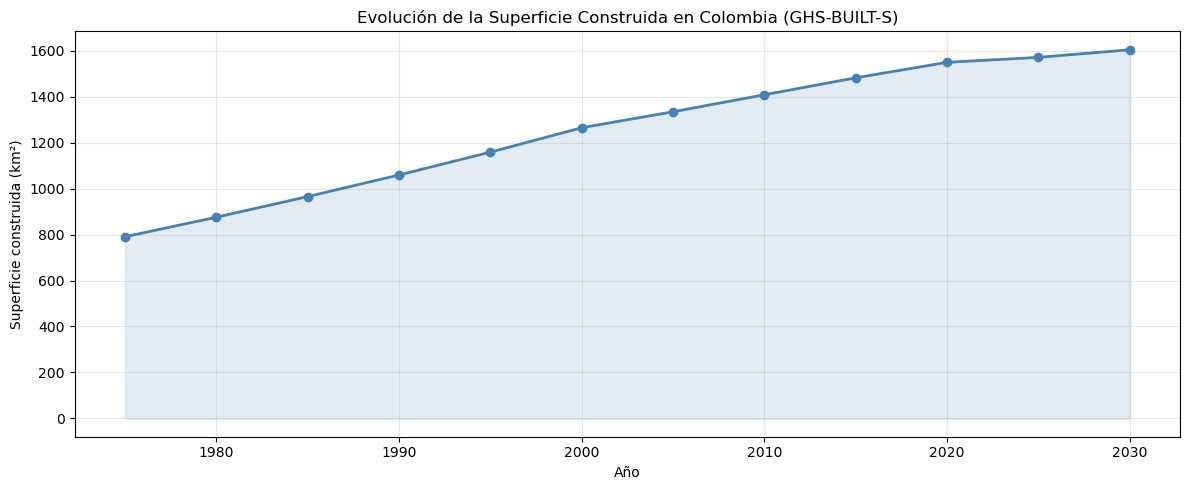

 year   total_km2
 1975  790.669734
 1980  875.711466
 1985  965.510187
 1990 1059.740873
 1995 1159.159406
 2000 1265.376824
 2005 1334.972119
 2010 1409.014786
 2015 1482.744697
 2020 1550.201602
 2025 1571.852591
 2030 1604.906185


In [7]:
serie = []
for year in COMMON_YEARS:
    p = CLIPPED_DIR / f"built_s_{year}_col.tif"
    if p.exists():
        with rasterio.open(p) as src:
            data = src.read(1, masked=True)
            total_m2 = float(data.sum())
        serie.append({"year": year, "total_km2": total_m2 / 1e6})

df_serie = pd.DataFrame(serie)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_serie["year"], df_serie["total_km2"], marker='o', linewidth=2, color='steelblue')
ax.fill_between(df_serie["year"], df_serie["total_km2"], alpha=0.15, color='steelblue')
ax.set_xlabel('Año')
ax.set_ylabel('Superficie construida (km²)')
ax.set_title('Evolución de la Superficie Construida en Colombia (GHS-BUILT-S)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_serie.to_string(index=False))

## 6. Serie temporal GHS-POP (población total Colombia)

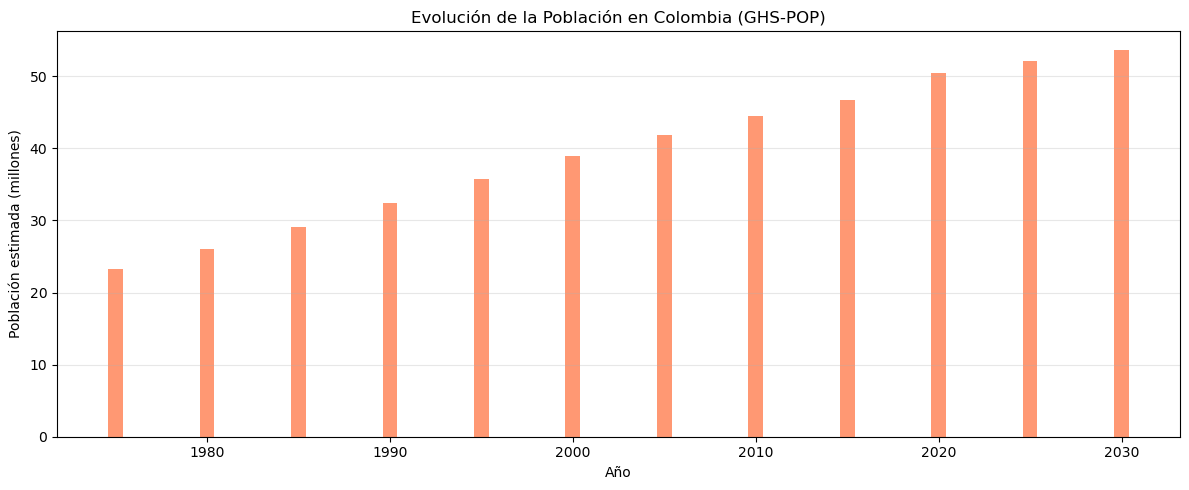

 year  poblacion_M
 1975    23.243014
 1980    25.989887
 1985    29.111103
 1990    32.354820
 1995    35.691300
 2000    38.902503
 2005    41.875027
 2010    44.439121
 2015    46.715345
 2020    50.474997
 2025    52.128118
 2030    53.622867


In [8]:
pop_serie = []
for year in GHSL_YEARS["pop"]:
    p = CLIPPED_DIR / f"pop_{year}_col.tif"
    if p.exists():
        with rasterio.open(p) as src:
            data = src.read(1, masked=True)
            total_pop = float(data.sum())
        pop_serie.append({"year": year, "poblacion_M": total_pop / 1e6})

df_pop = pd.DataFrame(pop_serie)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_pop["year"], df_pop["poblacion_M"], color='coral', alpha=0.8)
ax.set_xlabel('Año')
ax.set_ylabel('Población estimada (millones)')
ax.set_title('Evolución de la Población en Colombia (GHS-POP)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(df_pop.to_string(index=False))

## 7. Distribución de valores Hansen (pérdida forestal)

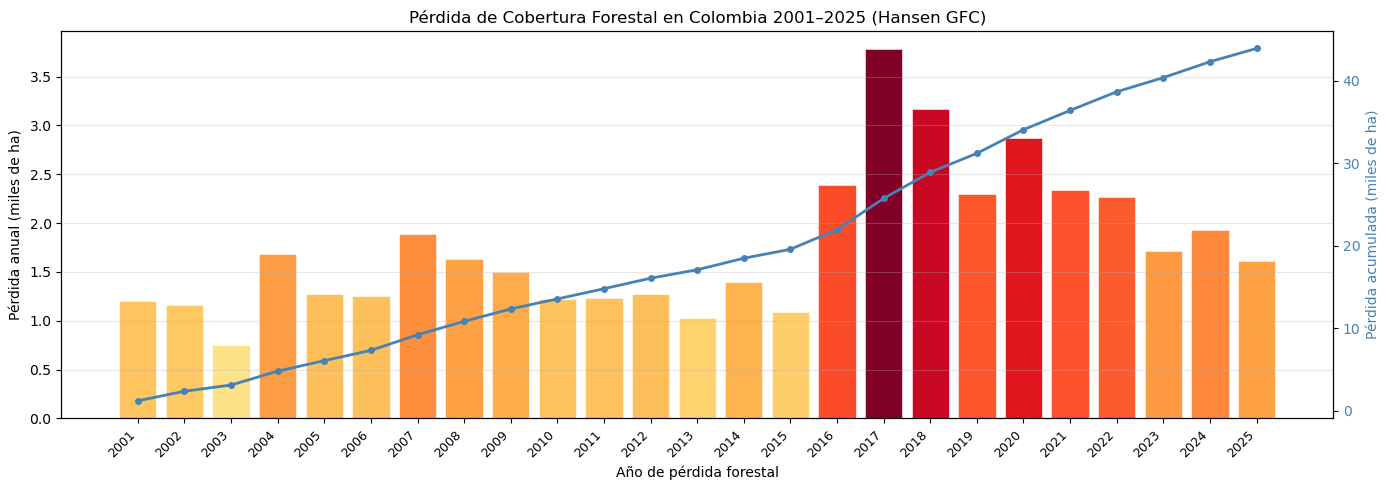

Pérdida forestal total 2001-2025: 43,929 ha  (0.04 Mha)
Año con mayor pérdida: 2017  (3,780 ha)


In [9]:
hansen_path = CLIPPED_DIR / "hansen_col.tif"
with rasterio.open(hansen_path) as src:
    hansen = src.read(1)

# Valores 1-25 = años 2001-2025; excluir 0 (sin pérdida) y 255 (nodata)
mask = (hansen >= 1) & (hansen <= 25)
values, counts = np.unique(hansen[mask], return_counts=True)
years_loss = 2000 + values.astype(int)
area_kha   = counts * 0.01 / 1000  # miles de ha

# Barras coloreadas por magnitud + línea acumulada en eje secundario
fig, ax1 = plt.subplots(figsize=(14, 5))
bar_colors = plt.cm.YlOrRd(area_kha / area_kha.max())
ax1.bar(years_loss, area_kha, color=bar_colors, edgecolor='white', linewidth=0.4)
ax1.set_xlabel('Año de pérdida forestal')
ax1.set_ylabel('Pérdida anual (miles de ha)')
ax1.set_title('Pérdida de Cobertura Forestal en Colombia 2001–2025 (Hansen GFC)')
ax1.set_xticks(years_loss)
ax1.set_xticklabels(years_loss, rotation=45, ha='right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = ax1.twinx()
ax2.plot(years_loss, np.cumsum(area_kha), color='steelblue', linewidth=2,
         marker='o', markersize=4)
ax2.set_ylabel('Pérdida acumulada (miles de ha)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.tight_layout()
plt.show()

total_ha = counts.sum() * 0.01
peak_yr  = years_loss[np.argmax(area_kha)]
print(f"Pérdida forestal total 2001-2025: {total_ha:,.0f} ha  ({total_ha/1e6:.2f} Mha)")
print(f"Año con mayor pérdida: {peak_yr}  ({area_kha.max()*1000:,.0f} ha)")

## 8. Distribución espacial de amenaza por MM

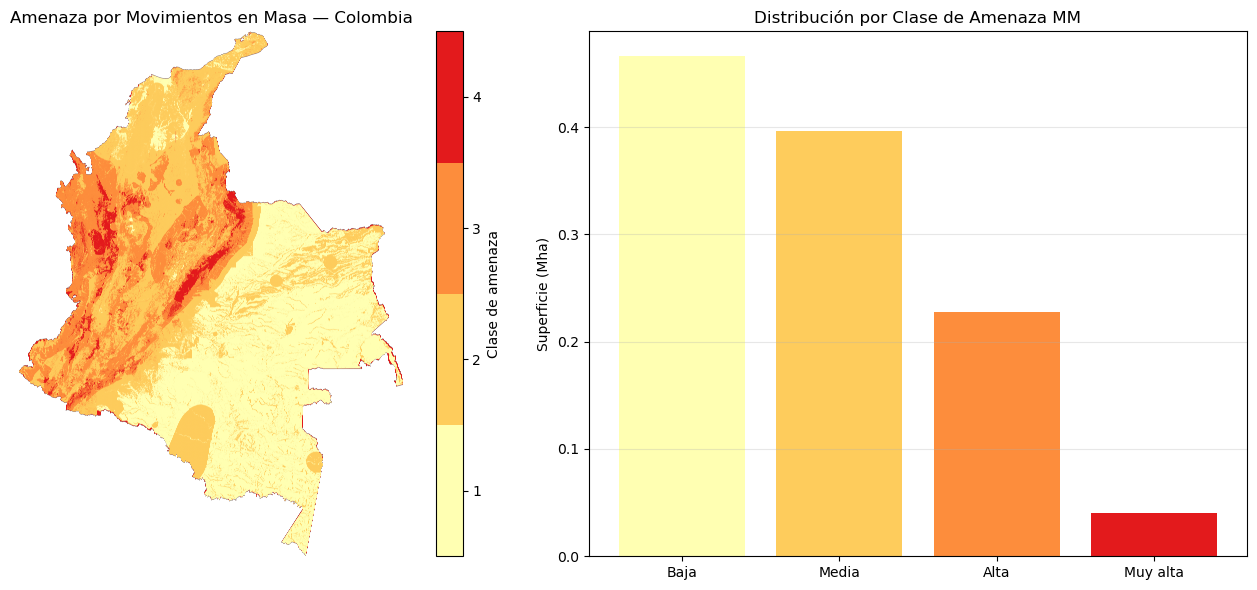

  Clase 1 (Baja):      466,011 ha  (41.2%)
  Clase 2 (Media):      396,525 ha  (35.1%)
  Clase 3 (Alta):      227,737 ha  (20.1%)
  Clase 4 (Muy alta):       39,964 ha  (3.5%)


In [10]:
mm_path = CLIPPED_DIR / "amenaza_mm_col.tif"
with rasterio.open(mm_path) as src:
    mm = src.read(1)

classes = {1: 'Baja', 2: 'Media', 3: 'Alta', 4: 'Muy alta'}
colors  = ['#ffffb2', '#fecc5c', '#fd8d3c', '#e31a1c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Mapa
cmap = mcolors.ListedColormap(colors)
im = ax1.imshow(np.where(mm == 0, np.nan, mm), cmap=cmap, vmin=0.5, vmax=4.5)
plt.colorbar(im, ax=ax1, ticks=[1,2,3,4], label='Clase de amenaza')
ax1.set_title('Amenaza por Movimientos en Masa — Colombia')
ax1.axis('off')

# Distribución por clase
cls_ha = [(cls, np.sum(mm == cls) * 0.01) for cls in [1, 2, 3, 4]]
ax2.bar([c[0] for c in cls_ha], [c[1] / 1e6 for c in cls_ha], color=colors)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels([classes[i] for i in [1,2,3,4]])
ax2.set_ylabel('Superficie (Mha)')
ax2.set_title('Distribución por Clase de Amenaza MM')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

for cls, ha in cls_ha:
    print(f"  Clase {cls} ({classes[cls]}): {ha:>12,.0f} ha  ({ha/sum(c[1] for c in cls_ha)*100:.1f}%)")

## 9. Amenaza por Inundación (vectorial)

Polígonos de inundación: 120
Columnas: ['SUSCEPTIBL', 'AREA_HA', 'SHAPE_Leng', 'SHAPE_Area', 'RULEID', 'geometry']
CRS: EPSG:9377


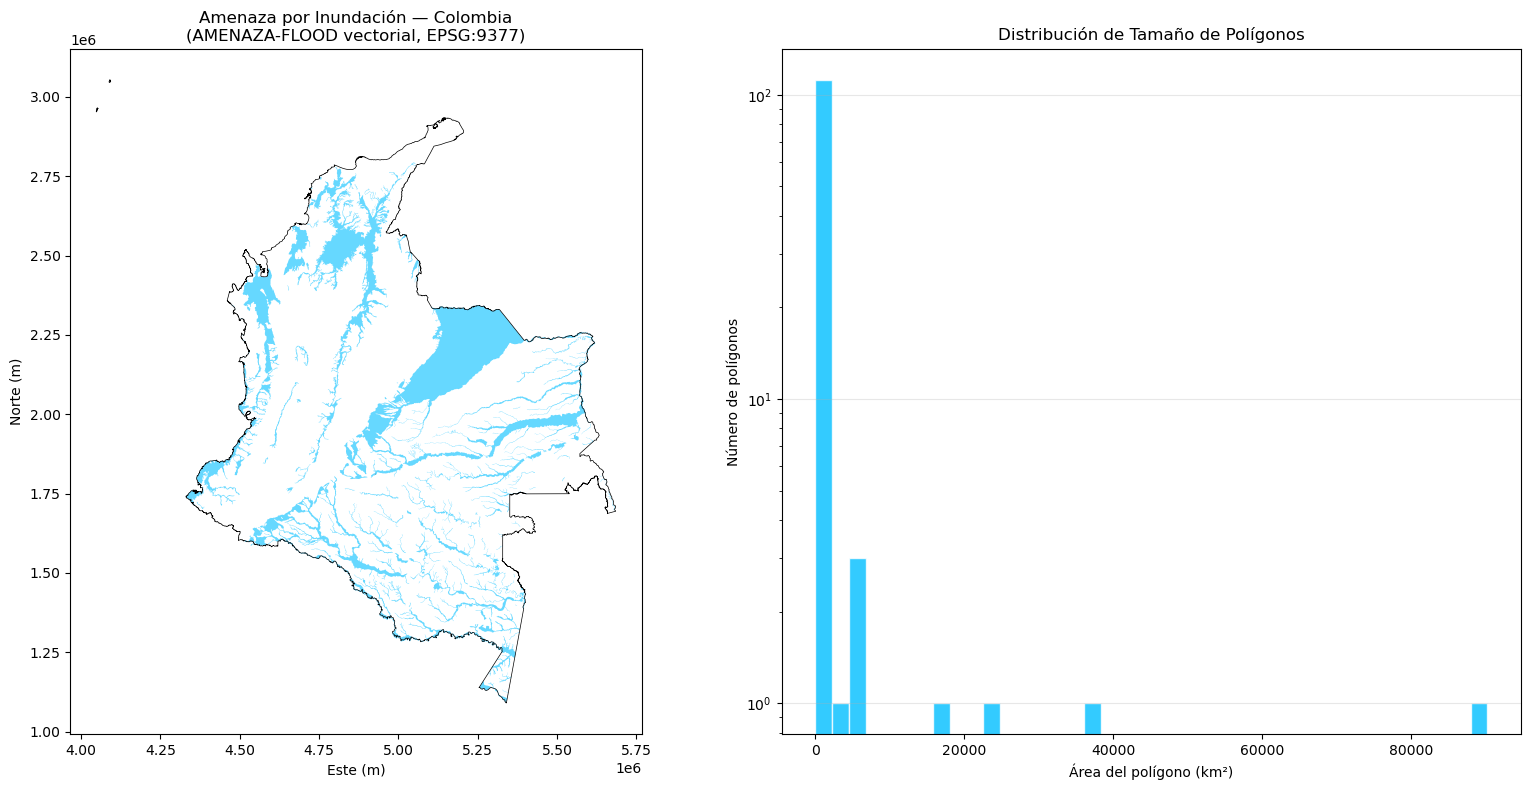


Área total en amenaza de inundación: 21,303,274 ha  (21.30 Mha)


In [11]:
flood_path = VECTORS_DIR / "amenaza_flood.gpkg"
gdf_flood  = gpd.read_file(flood_path)
gdf_limite = gpd.read_file(VECTORS_DIR / "limite_colombia_9377.gpkg")

print(f"Polígonos de inundación: {len(gdf_flood)}")
print(f"Columnas: {list(gdf_flood.columns)}")
print(f"CRS: {gdf_flood.crs}")

# Detectar columna de clase si existe
cls_col = next(
    (c for c in gdf_flood.columns
     if c.lower() in ("amenaza", "clase", "categoria", "nivel", "class", "hazard", "riesgo")),
    None
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Mapa ─────────────────────────────────────────────────────────────────────
ax = axes[0]
gdf_limite.boundary.plot(ax=ax, color='black', linewidth=0.5, zorder=2)
if cls_col:
    clases = sorted(gdf_flood[cls_col].dropna().unique())
    cmap_f = plt.cm.get_cmap('Blues', len(clases))
    for i, cls in enumerate(clases):
        gdf_flood[gdf_flood[cls_col] == cls].plot(
            ax=ax, color=cmap_f(i / max(len(clases)-1, 1)),
            alpha=0.7, edgecolor='none', label=str(cls)
        )
    ax.legend(title=cls_col, loc='lower right', fontsize=8)
else:
    gdf_flood.plot(ax=ax, color='deepskyblue', alpha=0.6, edgecolor='none')

ax.set_title('Amenaza por Inundación — Colombia\n(AMENAZA-FLOOD vectorial, EPSG:9377)')
ax.set_xlabel('Este (m)')
ax.set_ylabel('Norte (m)')

# ── Estadísticas de área ──────────────────────────────────────────────────────
ax2 = axes[1]
areas_km2 = gdf_flood.geometry.area / 1e6

if cls_col:
    cls_area = gdf_flood.groupby(cls_col).apply(lambda g: g.geometry.area.sum() / 1e4)  # ha
    cls_area = cls_area.sort_index()
    ax2.bar(cls_area.index.astype(str), cls_area.values / 1e3, color='deepskyblue', alpha=0.8)
    ax2.set_xlabel(cls_col)
    ax2.set_ylabel('Área (miles de ha)')
    ax2.set_title(f'Área en Amenaza de Inundación por {cls_col}')
else:
    ax2.hist(areas_km2, bins=40, color='deepskyblue', alpha=0.8, edgecolor='white')
    ax2.set_xlabel('Área del polígono (km²)')
    ax2.set_ylabel('Número de polígonos')
    ax2.set_title('Distribución de Tamaño de Polígonos')
    ax2.set_yscale('log')

ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

area_total_ha = gdf_flood.geometry.area.sum() / 1e4
print(f"\nÁrea total en amenaza de inundación: {area_total_ha:,.0f} ha  ({area_total_ha/1e6:.2f} Mha)")